# MNIST Digit Classifier — Neural Network from Scratch

A 2-layer neural network (784 → 64 → 10) built using **only NumPy** — no PyTorch, no TensorFlow.
Every component — forward propagation, backpropagation, and gradient descent — is implemented manually
from the underlying math, to build a first-principles understanding of how neural networks actually learn.

**Architecture:** Input (784) → Hidden (64, ReLU) → Output (10, Softmax)  
**Optimization:** Batch gradient descent (no momentum/Adam, by design — keeps the math visible)

In [23]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## 1. Load and Preprocess Data

Loading the MNIST dataset (28×28 grayscale digit images, flattened to 784-pixel vectors),
normalizing pixel values to [0, 1], and splitting into training (80%) and validation (20%) sets.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
data = pd.read_csv('/content/drive/MyDrive/NN_Data/MNISTtrain.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

In [27]:
train_data = data[0:int(0.8*m),:]
val_data = data[int(0.8*m):m,:]

X_train = train_data[:,1:].T
X_train = X_train / 255.0
Y_train = train_data[:,0]

X_val = val_data[:,1:].T
X_val = X_val / 255.0
Y_val = val_data[:,0]

## 2. Model Definition — Forward & Backward Propagation

**Forward pass:**
$$Z_1 = W_1 X + b_1, \quad A_1 = \text{ReLU}(Z_1)$$
$$Z_2 = W_2 A_1 + b_2, \quad A_2 = \text{softmax}(Z_2)$$

**Backward pass** (gradients via chain rule, using one-hot encoded labels $Y$):
$$dZ_2 = A_2 - Y, \quad dW_2 = \frac{1}{m} dZ_2 A_1^T, \quad db_2 = \frac{1}{m}\sum dZ_2$$
$$dZ_1 = W_2^T dZ_2 \odot \text{ReLU}'(Z_1), \quad dW_1 = \frac{1}{m} dZ_1 X^T, \quad db_1 = \frac{1}{m}\sum dZ_1$$

**Update rule** (gradient descent, learning rate $\alpha$):
$$W := W - \alpha \, dW, \quad b := b - \alpha \, db$$

In [28]:
def ReLU(X):
  return np.maximum(X,0)

def softmax(X):
  return np.exp(X)/sum(np.exp(X))

def one_hot_converter(X):
  one_hot_X = np.zeros((X.size, X.max()+1))
  one_hot_X[np.arange(X.size), X] = 1
  return one_hot_X.T

def get_prediction(X):
  return np.argmax(X,0)

def get_accuracy(predictions,X):
  return np.sum(predictions==X) / X.size


def init_parameters():
  W1 = np.random.rand(64,784)-0.5
  B1 = np.random.rand(64,1)-0.5
  W2 = np.random.rand(10,64)-0.5
  B2 = np.random.rand(10,1)-0.5
  return W1,B1,W2,B2

def forward_prop(W1,B1,W2,B2,X):
  A0 = X
  Z1 = W1.dot(A0) + B1
  A1 = ReLU(Z1)
  Z2 = W2.dot(A1) + B2
  A2 = softmax(Z2)
  return Z1,A1,Z2,A2

def backward_prop(W1,B1,W2,B2,Z1,A1,Z2,A2,X,Y):
  one_hot_Y = one_hot_converter(Y)
  A0 = X
  dZ2 = A2 - one_hot_Y
  dW2 = 1/m * dZ2.dot(A1.T)
  dB2 = 1/m * np.sum(dZ2)
  dZ1 = W2.T.dot(dZ2) * (Z1 > 0)
  dW1 = 1/m * dZ1.dot(A0.T)
  dB1 = 1/m * np.sum(dZ1)
  return dW1,dB1,dW2,dB2

def upd_parameters(W1,B1,W2,B2,dW1,dB1,dW2,dB2,alpha):
  W1 = W1 - alpha * dW1
  B1 = B1 - alpha * dB1
  W2 = W2 - alpha * dW2
  B2 = B2 - alpha * dB2
  return W1,B1,W2,B2

def gradient_descent(X, Y, alpha, iterations):
  W1, B1, W2, B2 = init_parameters()
  acc_history = []

  for i in range(iterations):
    Z1, A1, Z2, A2 = forward_prop(W1, B1, W2, B2, X)
    dW1, dB1, dW2, dB2 = backward_prop(W1, B1, W2, B2, Z1, A1, Z2, A2, X, Y)
    W1, B1, W2, B2 = upd_parameters(W1, B1, W2, B2, dW1, dB1, dW2, dB2, alpha)

    acc = get_accuracy(get_prediction(A2), Y)
    acc_history.append(acc)

    if (i % 100) == 0:
      print(f"Iteration number: {i}, Accuracy: {acc*100:.4f}%")

  return W1, B1, W2, B2, acc_history

In [29]:
X = X_train
Y = Y_train
alpha = 0.3
iterations = 5000
W1, B1, W2, B2, acc_history = gradient_descent(X, Y, alpha, iterations)


Iteration number: 0, Accuracy: 10.7530%
Iteration number: 100, Accuracy: 85.8631%
Iteration number: 200, Accuracy: 89.2232%
Iteration number: 300, Accuracy: 90.6369%
Iteration number: 400, Accuracy: 91.6399%
Iteration number: 500, Accuracy: 92.3393%
Iteration number: 600, Accuracy: 92.8423%
Iteration number: 700, Accuracy: 93.3304%
Iteration number: 800, Accuracy: 93.7202%
Iteration number: 900, Accuracy: 94.0744%
Iteration number: 1000, Accuracy: 94.3482%
Iteration number: 1100, Accuracy: 94.6369%
Iteration number: 1200, Accuracy: 94.8929%
Iteration number: 1300, Accuracy: 95.1161%
Iteration number: 1400, Accuracy: 95.2917%
Iteration number: 1500, Accuracy: 95.4911%
Iteration number: 1600, Accuracy: 95.6726%
Iteration number: 1700, Accuracy: 95.8244%
Iteration number: 1800, Accuracy: 95.9732%
Iteration number: 1900, Accuracy: 96.0982%
Iteration number: 2000, Accuracy: 96.2470%
Iteration number: 2100, Accuracy: 96.3631%
Iteration number: 2200, Accuracy: 96.4821%
Iteration number: 2300,

## 3. Training Results

In [30]:
Z1val, A1val, Z2val, A2val = forward_prop(W1, B1, W2, B2, X_val)
val_acc = get_accuracy(get_prediction(A2val), Y_val)
print("Validation accuracy = ", val_acc)

Validation accuracy =  0.9564285714285714


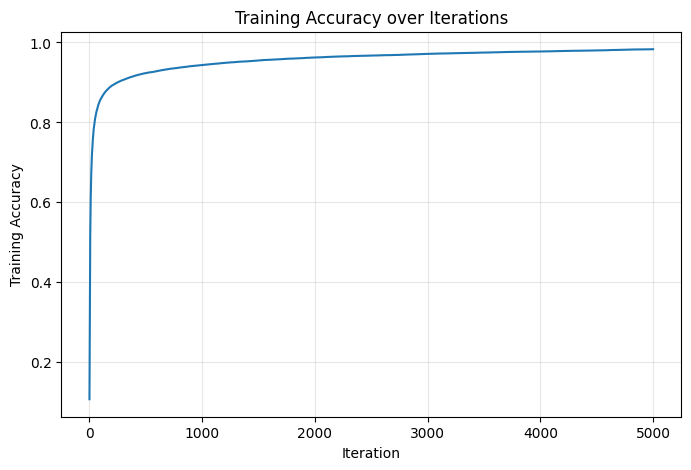

In [31]:
plt.figure(figsize=(8,5))
plt.plot(acc_history)
plt.xlabel("Iteration")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy over Iterations")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Sample Predictions

A grid of validation images with predicted vs. actual labels — green title means correct, red means incorrect.

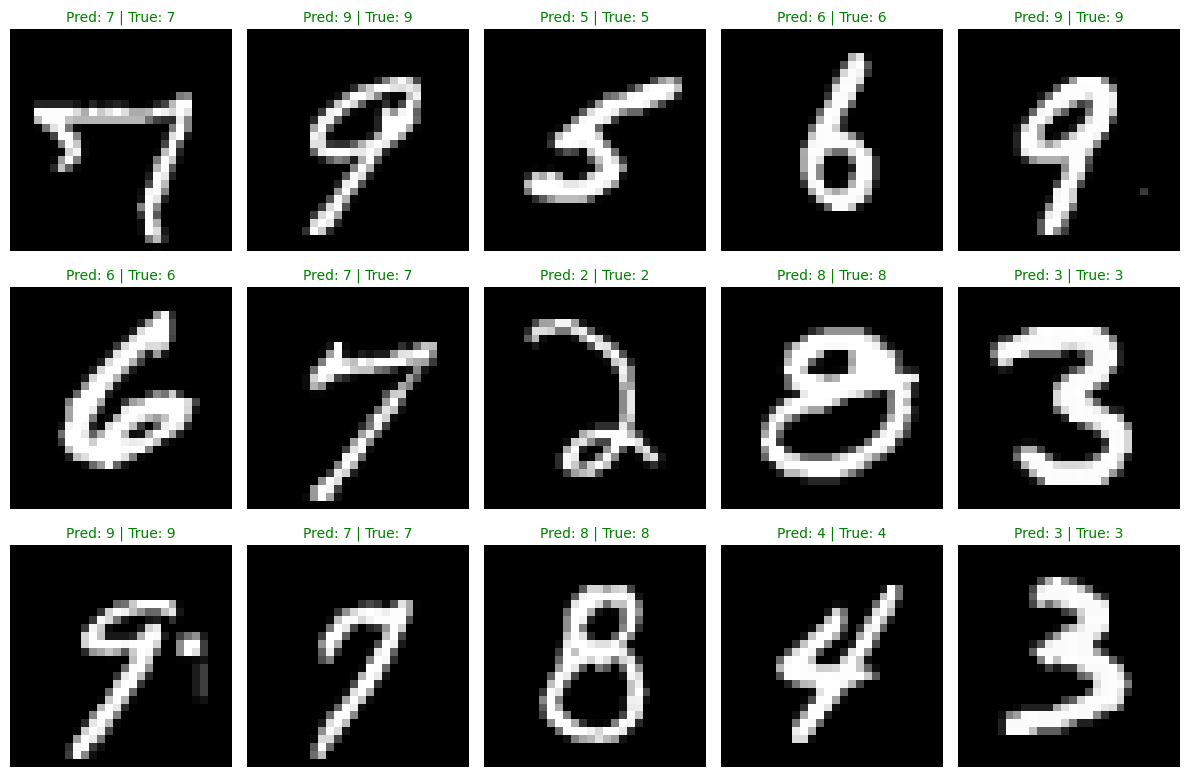

In [32]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.flatten()

for i, idx in enumerate(np.random.choice(X_val.shape[1], 15, replace=False)):
    _, _, _, A2 = forward_prop(W1, B1, W2, B2, X_val[:, idx, None])
    pred = get_prediction(A2)[0]
    actual = Y_val[idx]
    color = "green" if pred == actual else "red"

    axes[i].imshow(X_val[:, idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Pred: {pred} | True: {actual}", color=color, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 5. Conclusion

This network reaches **95.64%** validation accuracy using a single hidden layer
and plain gradient descent — no regularization, dropout, or adaptive optimizers.

**Possible improvements:**
- Add a second hidden layer or increase hidden units
- Use mini-batch gradient descent instead of full-batch
- Add momentum or Adam optimization for faster convergence
- Add L2 regularization to reduce overfitting

## Interactive Demo

Draw a digit below and the trained network will predict it live.

Predicted digit: 1
Confidence: 72.1 %


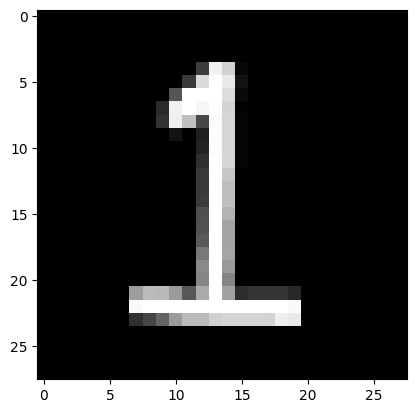

Predicted digit: 2
Confidence: 94.9 %


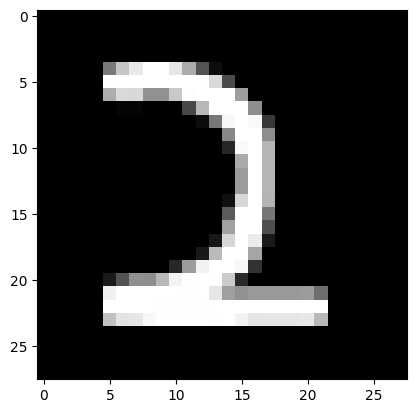

Predicted digit: 3
Confidence: 100.0 %


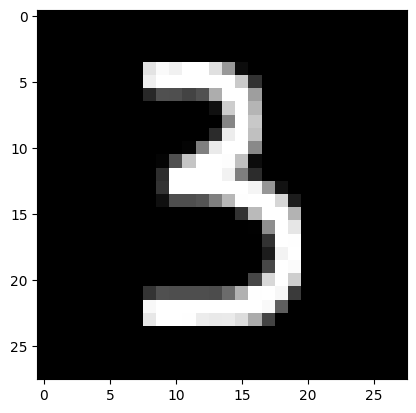

Predicted digit: 4
Confidence: 100.0 %


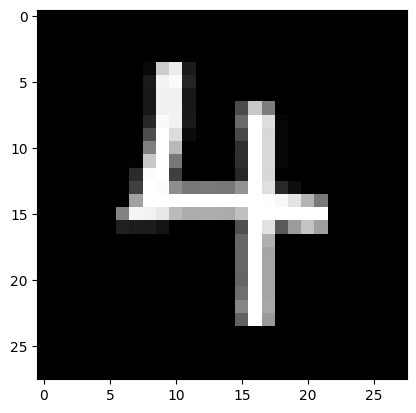

Predicted digit: 5
Confidence: 99.5 %


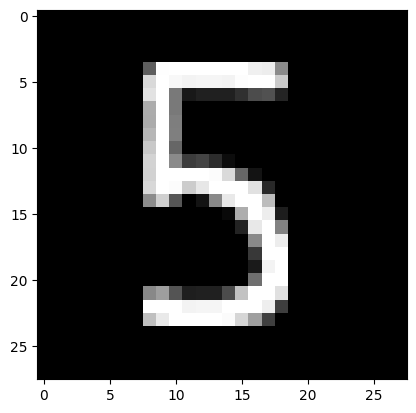

Predicted digit: 6
Confidence: 74.0 %


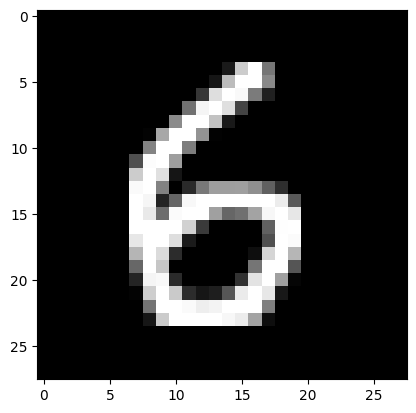

Predicted digit: 7
Confidence: 43.5 %


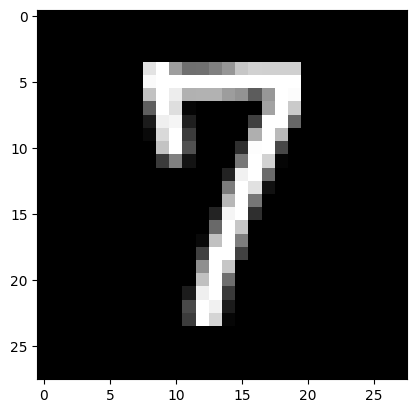

Predicted digit: 8
Confidence: 99.1 %


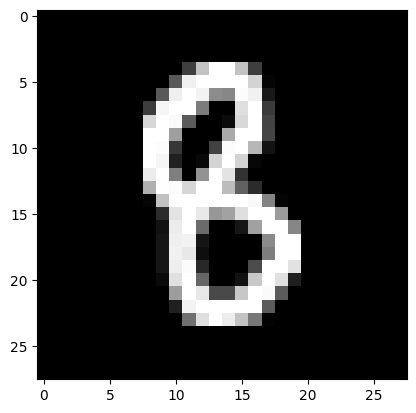

Predicted digit: 4
Confidence: 46.3 %


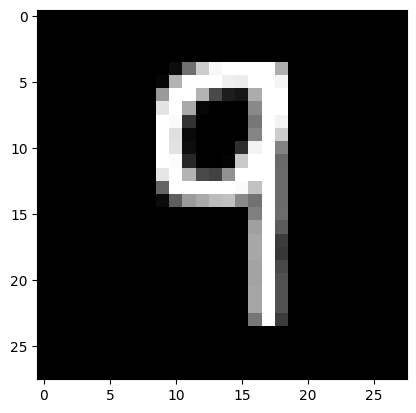

Predicted digit: 0
Confidence: 100.0 %


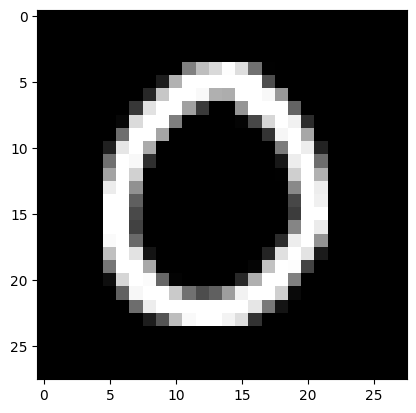

In [33]:
import numpy as np
from PIL import Image
import base64, io
from IPython.display import display, HTML
from google.colab import output
import matplotlib.pyplot as plt

def predict_digit(image_data_url):
    img_bytes = base64.b64decode(image_data_url.split(',')[1])
    img = Image.open(io.BytesIO(img_bytes)).convert('L')
    img_array = np.array(img).astype('float32')

    coords = np.argwhere(img_array > 20)
    if coords.size == 0:
        print("Nothing drawn.")
        return
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    cropped = img_array[y0:y1, x0:x1]

    h, w = cropped.shape
    scale = 20.0 / max(h, w)
    new_h, new_w = max(1, int(h * scale)), max(1, int(w * scale))
    digit_img = Image.fromarray(cropped).resize((new_w, new_h))

    canvas28 = Image.new('L', (28, 28), 0)
    upper_left = ((28 - new_w) // 2, (28 - new_h) // 2)
    canvas28.paste(digit_img, upper_left)

    final_array = np.array(canvas28).astype('float32') / 255.0
    X_input = final_array.reshape(784, 1)

    _, _, _, A2 = forward_prop(W1, B1, W2, B2, X_input)
    pred = get_prediction(A2)[0]
    probs = A2.flatten()
    print("Predicted digit:", pred)
    print("Confidence:", round(float(probs[pred]) * 100, 1), "%")

    plt.imshow(final_array, cmap='gray')
    plt.show()

output.register_callback('notebook.predict_digit', predict_digit)

canvas_html = """
<canvas id="canvas" width="280" height="280" style="border:1px solid black; background-color:black;"></canvas>
<br>
<button onclick="clearCanvas()">Clear</button>
<button onclick="predict()">Predict</button>

<script>
var canvas = document.querySelector('#canvas')
var ctx = canvas.getContext('2d')
ctx.lineWidth = 18
ctx.strokeStyle = 'white'
ctx.lineCap = 'round'
var drawing = false

canvas.addEventListener('mousedown', (e) => {
  drawing = true
  ctx.beginPath()
  ctx.moveTo(e.offsetX, e.offsetY)
})
canvas.addEventListener('mousemove', (e) => {
  if (drawing) {
    ctx.lineTo(e.offsetX, e.offsetY)
    ctx.stroke()
  }
})
canvas.addEventListener('mouseup', () => drawing = false)
canvas.addEventListener('mouseleave', () => drawing = false)

function clearCanvas() {
  ctx.clearRect(0, 0, canvas.width, canvas.height)
}

async function predict() {
  var dataUrl = canvas.toDataURL('image/png')
  await google.colab.kernel.invokeFunction('notebook.predict_digit', [dataUrl], {})
}
</script>
"""

display(HTML(canvas_html))